In [1]:
import sys, os
from os import path
sys.path.append("..")
import PCIEBoard
import Wave
import numpy as np
import time
%matplotlib inline
# import gc
import matplotlib.pyplot as plt
# from pylab import figure, savefig
# print(1)

In [2]:
#测试参数
# n_test_loop = 500
# n_test_aver = 5000
card_num=0
wave_cnt = 1                #系数组数（算法系数组数）
frame_per_coef = 1      #每个波形重复多少次
frame_size = 8192              #每个波形多长（单位k）

freq_list = [6000e6]#,100e6,10e6,20e6,30e6,40e6]       #AWG频率列表，不超过2个
#(8G-NCO)-f(AWG)
# freq_list_daq = [1.06e9,1.15e9,1.19e9,1.18e9,1.17e9,1.16e9] #算法频点列表，不超过2个

freq_list_daq = [2000e6,100e6,10e6,20e6,30e6,40e6]

alg_num = len(freq_list)      #算法系数个数

SR_DAQ = 4e9
SR_AWG = 6e9

awg_zone=1
awg_ch=8


In [3]:
wv_coef = Wave.Wave()
wv_coef.set_sample_rate(SR_DAQ)
def gen_coef(ad_core,freq_list, offset_freq):  # offset_freq：是多个波形的时候会用，实现频率递增，步进是波形长度的倒数
    _coef = []  # gen_coef这个函数是定义的算法系数
    #     for idx in range(alg_num):
    for freq in freq_list:
        iq = wv_coef.gen_i_line_q_line(freq=freq + offset_freq, length=frame_size /SR_DAQ)
        _coef.append([iq[0], iq[1]])
    print(_coef)
    return _coef

def gen_adc_iq_data(ad_core,wave_cnt=1, frame_per_coef=100, frame_size=4, freq_list=None):  # gen_adc_iq_data函数定义的是ADC的数据
    coefData = []
    alg_num = len(freq_list)
    # for t in np.arange(1, wave_cnt + 1):
    for t in np.arange(0, wave_cnt ):
        offset_freq = t * 5e6
        coefData.append(gen_coef(ad_core,freq_list, offset_freq))
    coefData = np.asarray(coefData)
    shape = coefData.shape
    print(f'ADC 数据量：{frame_per_coef * frame_size * 4 * wave_cnt * 1024:,} bytes')
    print(f'算法 数据量：{frame_per_coef * alg_num * 16 * wave_cnt:,} bytes')
    return coefData


def calc_alg_iq(ad_core):
    '''计算AD_core中采集数据对应的IQ 幅值，每个频率1个结果，波形数据计算的一个，板上算法数据计算的1个'''
    b = ad_core.alg_iqDataf.mean(axis=3)
    fpga_calc = np.sqrt(np.sum(b * b, axis=2))

    b = ad_core.iqDataf.mean(axis=3)
    pc_calc = np.sqrt(np.sum(b * b, axis=2))
    return pc_calc, fpga_calc

from sklearn.decomposition import PCA
def calc_alg_phase_scan_eccentricity(alg_x,alg_y):
    model = PCA(2)
    model.fit(np.vstack([alg_x,alg_y]).T)
    print(model.explained_variance_ratio_)
    return model.explained_variance_ratio_[0]



In [4]:
#AWG波形配置
# def SetNCO(board,ch,fMHZ):
#     tile,blk = board.ch2tile_blk(ch)
#     # print(f'CH{ch} ---> tile{tile},block{blk}')
#     return board.XRFdcSetMixerSettings(tile=tile,block=blk,freq=fMHZ)

def SetZone(board,ch,zone):
    tile,blk = board.ch2tile_blk(ch)
    return board.XRFdcSetNyquistZone(tile=tile,block=blk,nyquist_zone=zone)

wv = Wave.Wave()
wv.set_sample_rate(SR_AWG)
def config_awg(awg,phase=0,amp=1,bShowWave = False):
    ch = awg_ch
    ls_wv = []
    for freq in freq_list:
        wave = wv.gen_i_line_q_line(freq, length=frame_size/SR_DAQ,phase = phase,amp=amp)[0]
        ls_wv.append(wave)
    for i in range(1,len(ls_wv)):
        ls_wv[0]+=ls_wv[i]
    wave = ls_wv[0]/len(ls_wv)

    # wave = wv.gen_iq_line(freq=freq_list[0], length=1e-6,phase = phase)[:frame_size*4]
    # for i in range(1,alg_num):
    #     wave2 = wv.gen_iq_line(freq=freq_list[i], length=1e-6,phase = phase)#[:frame_size*4]
    #     for j in range(len(wave)):
    #         wave[j] = (wave[j]+wave2[j])/2
    if bShowWave:
        print('Wave len: ',len(wave))
        plt.figure()
        plt.plot(wave)

    wave_list=[]
    wave_list.append(awg.gen_wave_unit(wave, 'trig',0))
    # print(len(wave))
    # awg.SetOffsetVolt(1,0)
    awg.SetLoop(ch,10000)
    awg.wave_compile(ch, wave_list, is_continue=False)
    awg.Start(ch)

In [5]:
#DAQ采集配置
def config_daq(ad_core,trig_delay=2e-7):
    coef_data = gen_adc_iq_data(ad_core,wave_cnt, frame_per_coef, frame_size, freq_list_daq)
    print(coef_data.shape)
    ad_core.configCapture(triggerSource='External',
                  frame_cnt=wave_cnt*frame_per_coef,
                  frameSize=frame_size,
                  isTestData=False)
    ad_core.write_coef(coef_data)
    
    # print(1)
    ad_core.set_mode('raw_alg')
    ad_core.set_trig_delayx32(trig_delay)#daq触发延时采集时间(s)


In [6]:
def config_daq_new_samp(ad_core):
    ad_core.set_mode('raw_alg')
    ad_core.startCapture()

In [7]:
import mf_trig3 as mf_trig
ext_tb = mf_trig.TrigBoard()
ext_tb.connect('192.168.11.224')

def Config_trig(tb,freq=1e3,count=1):
    tb.trig_switch_ext()
    ext_tb.set_internal_trig(0,freq=freq,count=count)
    ext_tb.start_internal_trig(0)
    # tb.set_internal_trig(0,freq,count)
    # tb.enable_trig_output(0)
    # tb.start_internal_trig(0)
    
def Config_trig_new(tb):
    ext_tb.start_internal_trig(0)

In [8]:
def test_loop(nTest = 360,bShowFig = False):
    test_res = []
    
#     config_awg()
    daq = PCIEBoard.PCIEBoard()
    if daq.open_device(card_num):
        # SetNCO(daq,awg_ch,awg_nco)
        # SetZone(daq,awg_ch,awg_zone)
        config_daq(daq)
        Config_trig(daq,2e3,frame_per_coef*wave_cnt)
        # Config_trig(daq,1e4,0) 
        for iTest in range(nTest):
            config_awg(daq,amp=iTest/nTest)
            # config_awg(daq,iTest/nTest*np.pi)
            config_daq_new_samp(daq)
            time.sleep(0.1)
            Config_trig_new(daq)
            daq.get_Data()
            if bShowFig:
                plt.figure()
                plt.plot(daq.i_data[0])
                plt.show()
            daq.get_algData(alg_num=alg_num)
    #         print(ad_core.alg_iqDataf.shape)
            test_res.append(daq.alg_iqDataf.mean(axis=3)[0])
        
        daq.close_device()
        return test_res
    else:
        print('打开设备失败')

In [9]:
awg_ch=8
res = test_loop(50)
print(frame_per_coef*wave_cnt)

[[array([ 1., -1.,  1., ..., -1.,  1., -1.]), array([ 0.00000000e+00,  1.22464680e-16, -2.44929360e-16, ...,
        1.75080977e-13, -1.66379047e-12, -4.85478838e-13])], [array([ 1.00000000e+00,  9.87688341e-01,  9.51056516e-01, ...,
       -1.56434465e-01, -3.77147885e-14,  1.56434465e-01]), array([ 0.        ,  0.15643447,  0.30901699, ..., -0.98768834,
       -1.        , -0.98768834])], [array([ 1.        ,  0.99987663,  0.99950656, ..., -0.98510933,
       -0.98768834, -0.99002366]), array([0.        , 0.01570732, 0.03141076, ..., 0.1719291 , 0.15643447,
       0.14090123])], [array([1.        , 0.99950656, 0.99802673, ..., 0.94088077, 0.95105652,
       0.96029369]), array([ 0.        ,  0.03141076,  0.06279052, ..., -0.33873792,
       -0.30901699, -0.27899111])], [array([ 1.        ,  0.99888987,  0.99556196, ..., -0.86863151,
       -0.89100652, -0.91140328]), array([0.        , 0.04710645, 0.09410831, ..., 0.49545867, 0.4539905 ,
       0.41151436])], [array([1.        , 0.99

(1, 2)
[1.00000000e+00 3.67488929e-33]


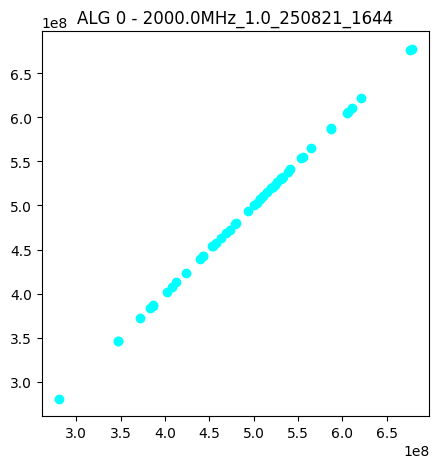

In [10]:
print(res[0].shape)

for iAlg in range(alg_num):
    ec = calc_alg_phase_scan_eccentricity(np.array(res)[:,iAlg,0],np.array(res)[:,iAlg,1])
    
    plt.figure(figsize=(5,5))
    # plt.title('ALG '+str(iAlg))
    plt.title(f'ALG {iAlg} - {freq_list_daq[iAlg]/1e6}MHz_{round(ec,6)}_{time.strftime("%y%m%d_%H%M", time.localtime())}')
    for i in range(len(res)):
        plt.scatter(res[i][iAlg][0], res[i][iAlg][1],c='aqua')